In [ ]:
# =====================================================
# 1. Calendar Spread Construction
#
# In this section, we construct a calendar spread using two AAPL options with 
# different maturities. The objective is to create a structure that is net long 
# gamma around the selected strike.
#
# The construction process includes:
# - Selecting appropriate expiries
# - Defining the strike selection logic
# - Determining long and short positions for each option leg
# =====================================================

In [22]:
# === Prepare the data from CSV files ===
import pandas as pd

# Load historical option data
options = pd.read_csv("AAPL_recent_data.csv", sep=";")
options.columns = options.columns.str.strip().str.lower()
options["date"] = pd.to_datetime(options["date"], dayfirst=True)
options["exdate"] = pd.to_datetime(options["exdate"], dayfirst=True)

# Load historical stock price data
stock = pd.read_csv("AAPL_historical_stock_price.csv", sep=";")
stock.columns = stock.columns.str.strip().str.lower()
stock["date"] = pd.to_datetime(stock["date"], dayfirst=True, errors="coerce")
stock["close"] = stock["close"].replace('[\$,]', '', regex=True).astype(float)

# Merge stock price to options by date
options = options.merge(stock[["date", "close"]], on = "date", how = "left")

# Convert strike prices to actual price (divide by 1000)
options['strike_price'] = options['strike_price'] / 1000

# Calculate days to expiry
options['days_to_expiry'] = (options['exdate'] - options['date']).dt.days

# Calculate moneyness
options['moneyness'] = options['strike_price'] / options['close'] 


# === START FILTERING ===
# Filter only put option
options = options[options["cp_flag"] == "P"]

# Filter options for today's date
options_on_date = options[options['date'] == pd.to_datetime('2025-06-13')].copy()

# Filter for ATM options (moneyness between 0.97 and 1.03)
atm_options = options_on_date[(options_on_date['moneyness'] >= 0.97) & (options_on_date['moneyness'] <= 1.03)].copy()

# Separate into short-term and long-term based on days to expiry
short_term = atm_options[(atm_options['days_to_expiry'] >= 7) & (atm_options['days_to_expiry'] <= 35)].copy() # 7-35 days
long_term = atm_options[(atm_options['days_to_expiry'] >= 42) &(atm_options['days_to_expiry'] <= 126)].copy() # 42-126 days

print("SHORT-TERM PUT OPTIONS")
print(short_term[['strike_price', 'exdate', 'days_to_expiry', 'moneyness', 'best_bid', 'best_offer', 'volume', 'impl_volatility']])
print("\n\nLONG-TERM PUT OPTIONS")
print(long_term[['strike_price', 'exdate', 'days_to_expiry', 'moneyness', 'best_bid', 'best_offer', 'volume', 'impl_volatility']])

C:\Users\hanse\AppData\Local\Temp\ipykernel_9396\3747653216.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  options = pd.read_csv("AAPL_recent_data.csv", sep=";")


SHORT-TERM PUT OPTIONS
        strike_price     exdate  days_to_expiry  moneyness  best_bid  \
669753         192.5 2025-06-20               7   0.979893      1.62   
669754         192.5 2025-06-27              14   0.979893      2.73   
669755         195.0 2025-06-20               7   0.992619      2.44   
669757         195.0 2025-06-27              14   0.992619      3.65   
669881         195.0 2025-07-03              20   0.992619      4.40   
669882         195.0 2025-07-11              28   0.992619      5.20   
669883         195.0 2025-07-18              35   0.992619      5.95   
669884         197.5 2025-06-20               7   1.005345      3.55   
669975         197.5 2025-06-27              14   1.005345      4.80   
669976         200.0 2025-06-20               7   1.018071      5.10   
670061         200.0 2025-06-27              14   1.018071      6.20   
670062         200.0 2025-07-03              20   1.018071      6.90   
670163         200.0 2025-07-11          

In [23]:
# Looking at the available put options based on our filters, 
# we select 20 June (7-day) and 15 August (63-day) maturities as our short-term and long-term legs, 
# as they show the highest volume of 33,277 and 3,030 with a tight bid-ask spread of $0.04 and $0.1, 
# ensuring strong liquidity and reliable execution.

# === CALENDAR SPREAD ===
# Buy short-term put option, Sell long-term put option
#      date         expiry_date type strike_price best_bid best_offer volume impl_vol ttm_days moneyness
# buy  13/06/2025	20/06/2025	P	 195000	      2.44     2.48	      33277	 0.28416  7	       0.992618987   
# sell 13/06/2025	15/08/2025	P	 195000	      9.05	   9.15	      3030	 0.315939 63	   0.992618987  

print("Selected short-term put option:")
print(short_term[['strike_price', 'exdate', 'days_to_expiry', 'moneyness', 'best_bid', 'best_offer', 'volume', 'impl_volatility']].iloc[[2]])
print("\n\nSelected long-term put option:")
print(long_term[['strike_price', 'exdate', 'days_to_expiry', 'moneyness', 'best_bid', 'best_offer', 'volume', 'impl_volatility']].iloc[[2]])

Selected short-term put option:
        strike_price     exdate  days_to_expiry  moneyness  best_bid  \
669755         195.0 2025-06-20               7   0.992619      2.44   

        best_offer  volume  impl_volatility  
669755        2.48   33277          0.28416  


Selected long-term put option:
        strike_price     exdate  days_to_expiry  moneyness  best_bid  \
670345         195.0 2025-08-15              63   0.992619      9.05   

        best_offer  volume  impl_volatility  
670345        9.15    3030         0.315939  


In [ ]:
# ===================================================
# 2. Payoff Analysis
#
# In this section, we analyze the terminal payoff structure of the constructed
# calendar spread. The payoff diagram at maturity is plotted to visualize
# the nonlinear payoff profile of the option structure.
#
# The analysis focuses on:
# - Identifying price regions where the strategy generates profit
# - Identifying regions where losses occur
# - Understanding the gamma characteristics of the structure
#
# This helps provide intuition for how the calendar spread behaves under
# different underlying price scenarios.
# ===================================================

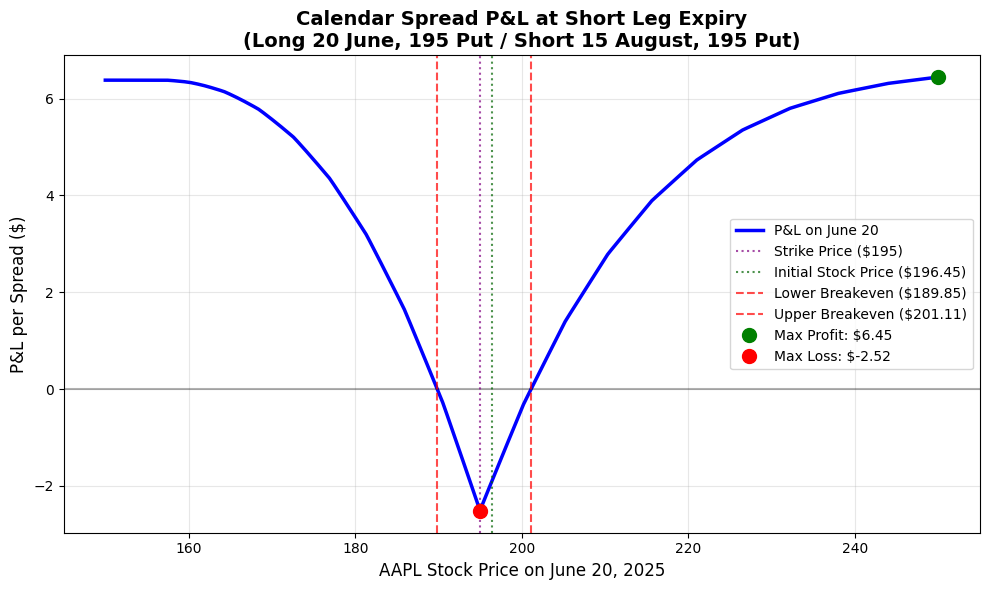

In [25]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# === Initial parameters ===
K = 195             # Strike price
S = 196.45          # Current stock price
T = 56/365          # Long-term option days to expiry on 20 June 2025
# U.S. Treasury bill rates
week_4_r = 0.0419   # 4 weeks rates
week_6_r = 0.0424   # 6 weeks rates
week_8_r = 0.0445   # 8 weeks rates
week_13_r = 0.0436  # 13 weeks rates
# Current long-term option implied volatility
sigma = 0.315939


# === Define binomial model for American put option ===
def binomial_american_put(S, K, T, r_annual, sigma, N):
    # If the option has expired or zero time to maturity, return intrinsic value
    if T <= 0:
        return max(K - S, 0)
    
    # Convert annual rate to continuous rate
    r = np.log(1 + r_annual)
    
    # Time step
    dt = T / N
    
    u = np.exp(sigma * np.sqrt(dt))    # Up factor
    d = 1.0 / u                        # Down factor
    p = (np.exp(r * dt) - d) / (u - d) # Risk-neutral probability
    
    # Initialize stock price tree
    stock_tree = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            # Stock price before any dividends
            stock_tree[i, j] = S * (u ** j) * (d ** (i - j))
    
    # Initialize and calculate option payoff at maturity
    option_tree = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        option_tree[N, j] = max(K - stock_tree[N, j], 0)
    
    # Backward induction payoff calculation
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            option_tree[i, j] = max(K - stock_tree[i, j], np.exp(-r * dt) * (p * option_tree[i + 1, j + 1] + (1 - p) * option_tree[i + 1, j]))
    
    return option_tree[0, 0]
    

# === Generate range of possible AAPL stock prices at expiry date 20 June 2025 ===
price_range = np.linspace(150, 250, 1001) # 1001 numbers from 150 to 250
    
# === Calculate PnL for each possible stock price in price_range ===
PnL_values = []
for St in price_range:
    # 20 June short-term option
    short_put_price = max(K-St, 0)
    
    # 15 August long-term option
    dividend_amount = 0.26                        # $0.26 per share on 14 August 2025
    discount_factor = 1 / (1 + week_8_r * 55/365) # 55 days from dividend payable from 20 june
    pv_dividend = dividend_amount * discount_factor
    S_adj = St - pv_dividend
    long_put_price = binomial_american_put(S_adj, K, T, week_8_r, sigma, N=100) # 100 time steps for numerical accuracy
    
    # Calculate PnL if we close both positions on June 20
    PnL = (short_put_price - 2.46) + (9.10 - long_put_price)
    PnL_values.append(PnL)

# === Find approximate breakeven points ===
breakevens = []
for i in range(len(price_range)-1):
    if PnL_values[i] * PnL_values[i+1] <= 0:  # Sign change
        # Linear interpolation
        S1, S2 = price_range[i], price_range[i+1]
        P1, P2 = PnL_values[i], PnL_values[i+1]
        breakeven = S1 - P1 * (S2 - S1) / (P2 - P1)
        breakevens.append(breakeven)

# === Plot PnL ===
plt.figure(figsize=(10, 6))

# Plot the P&L curve
plt.plot(price_range, PnL_values, color='blue', linewidth=2.5, label='P&L on June 20')

# Add horizontal zero line
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add vertical lines for key prices
plt.axvline(x=K, color='purple', linestyle=':', alpha=0.7, label=f'Strike Price (${K})')
plt.axvline(x=196.45, color='darkgreen', linestyle=':', alpha=0.7, label=f'Initial Stock Price (${196.45})')
plt.axvline(x=breakevens[0], color='red', linestyle='--', alpha=0.7, label=f'Lower Breakeven (${breakevens[0]:.2f})')
plt.axvline(x=breakevens[1], color='red', linestyle='--', alpha=0.7, label=f'Upper Breakeven (${breakevens[1]:.2f})')

# Find and mark maximum profit and loss 
max_pnl = max(PnL_values)
min_pnl = min(PnL_values)
max_idx = np.argmax(PnL_values)
min_idx = np.argmin(PnL_values)
plt.plot(price_range[max_idx], max_pnl, 'go', markersize=10, label=f'Max Profit: ${max_pnl:.2f}')
plt.plot(price_range[min_idx], min_pnl, 'ro', markersize=10, label=f'Max Loss: ${min_pnl:.2f}')

# Labels and formatting
plt.xlabel('AAPL Stock Price on June 20, 2025', fontsize=12)
plt.ylabel('P&L per Spread ($)', fontsize=12)
plt.title('Calendar Spread P&L at Short Leg Expiry\n(Long 20 June, 195 Put / Short 15 August, 195 Put)', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()

In [ ]:
# ===================================================
# 3. Pricing
#
# The calendar spread is priced using historical option market data as of
# the trade date. To obtain appropriate pricing inputs, historical data is
# used to estimate forward-looking volatility assumptions.
#
# The pricing process includes:
# - Deriving a reasonable volatility estimate from historical data
# - Valuing each option leg of the calendar spread
# - Computing the total portfolio value at the trade date
#
# Any modeling assumptions used in the pricing process are clearly stated,
# such as approximating American options as European and assumptions for
# interest rates or dividends.
# ===================================================

In [27]:
# === VOLATILITY FORECAST ===

# Filter options near-ATM
options_atm = options[(options["moneyness"] >= 0.97) & (options["moneyness"] <= 1.03)]

# Filter by time to maturity range
short_term_iv = options_atm[(options_atm["days_to_expiry"] >= 5) & (options_atm["days_to_expiry"] <= 10)] # 5-10 days to expiry
long_term_iv = options_atm[(options_atm["days_to_expiry"] >= 49) & (options_atm["days_to_expiry"] <= 77)] # 49-77 days to expiry

# Extract implied volatility 
short_term_iv_series = short_term_iv["impl_volatility"]
long_term_iv_series = long_term_iv["impl_volatility"]

# Aggregate by date (mean implied volatility of all ATM options per date)
daily_short_term_iv = short_term_iv.groupby('date')['impl_volatility'].mean().reset_index()
daily_long_term_iv = long_term_iv.groupby('date')['impl_volatility'].mean().reset_index()

# Make sure the data is sorted by date
daily_short_term_iv = daily_short_term_iv.sort_values('date')
daily_long_term_iv = daily_long_term_iv.sort_values('date')

# Calculate rolling mean of implied volatility for each series
daily_short_term_iv['rolling_iv_7d'] = daily_short_term_iv['impl_volatility'].rolling(window=7, min_periods=3).mean()
daily_long_term_iv['rolling_iv_63d'] = daily_long_term_iv['impl_volatility'].rolling(window=63, min_periods=20).mean()

# Extract the rolling implied volatility for 13 June 2025
short_term_forecast = daily_short_term_iv.loc[daily_short_term_iv['date'] == pd.to_datetime('2025-06-13'), 'rolling_iv_7d'].iloc[-1]
long_term_forecast = daily_long_term_iv.loc[daily_long_term_iv['date'] == pd.to_datetime('2025-06-13'), 'rolling_iv_63d'].iloc[-1]


print("ROLLING MEAN VOLATILITY FORECAST:")
print(f"7-day rolling mean for short-term (7-day) puts: {short_term_forecast:.4f} ({short_term_forecast*100:.2f}%)")
print(f"63-day rolling mean for long-term (63-day) puts: {long_term_forecast:.4f} ({long_term_forecast*100:.2f}%)")
print("\n\nCOMPARISON WITH CURRENT MARKET IMPLIED VOLATILITY:")
print(f"Short-term put: 0.2842 (28.42%)")
print(f"Long-term put: 0.3159 (31.59%)")

ROLLING MEAN VOLATILITY FORECAST:
7-day rolling mean for short-term (7-day) puts: 0.2872 (28.72%)
63-day rolling mean for long-term (63-day) puts: 0.3212 (32.12%)


COMPARISON WITH CURRENT MARKET IMPLIED VOLATILITY:
Short-term put: 0.2842 (28.42%)
Long-term put: 0.3159 (31.59%)


In [28]:
# === PRICING THE CONSTRUCTED CALENDAR SPREAD ===

# U.S. Treasury bill rates
week_4_r = 0.0419   # 4 weeks rates
week_6_r = 0.0424   # 6 weeks rates
week_8_r = 0.0445   # 8 weeks rates
week_13_r = 0.0436  # 13 weeks rates

# === Parameters ===
S = 196.45                                              # Current stock price
K = 195                                                 # Strike price
T_short = 7/365                                         # Time to maturity for short-term put (in years)
T_long = 63/365                                         # Time to maturity for long-term put (in years)
r_7 = 0.0419 + (1-4)/(6-4) * (week_6_r - week_4_r)      # Interpolated 1 week (7-day) risk-free rates
r_63 = 0.0445 + (9-8)/(13-8) * (week_13_r - week_8_r)   # Interpolated 9 week (63-day) risk-free rates
sigma_short_forecast = short_term_forecast              # Forecasted volatility for short-term put
sigma_long_forecast = long_term_forecast                # Forecasted volatility for long-term put
N_short = 100                                           # Number of steps for short-term put
N_long = 200                                            # Number of steps for long-term put

# Short-term put pricing (7-day): NO DIVIDEND
short_put_price = binomial_american_put(S=S, K=K, T=T_short, r_annual=r_7, sigma=sigma_short_forecast, N=N_short)

# Long-term put pricing (63-day): WITH DIVIDEND
dividend_amount = 0.26                           # $0.26 per share on 14 August 2025
discount_factor = 1 / (1 + r_63 * 62/365)        # Discount factor
pv_dividend = dividend_amount * discount_factor  # Present value of dividend
S_adjusted = S - pv_dividend                     # Adjusted stock price
long_put_price = binomial_american_put(S=S_adjusted, K=K, T=T_long, r_annual=r_63, sigma=sigma_long_forecast, N=N_long)

# Calendar spread price
spread_price = short_put_price - long_put_price


print("PRICING:")
print(f"Short-term put (7-day, no dividend): ${short_put_price:.4f}")
print(f"Long-term put (63-day, with dividend): ${long_put_price:.4f}")
print(f"Calendar spread price: ${spread_price:.4f}")

# Market comparison
market_short = 2.46
market_long = 9.10
market_spread = market_short - market_long

print(f"\nMARKET PRICES:")
print(f"Short-term put: ${market_short:.2f}")
print(f"Long-term put: ${market_long:.2f}")
print(f"Calendar spread price: ${market_spread:.2f}")


PRICING:
Short-term put (7-day, no dividend): $2.3720
Long-term put (63-day, with dividend): $9.2077
Calendar spread price: $-6.8356

MARKET PRICES:
Short-term put: $2.46
Long-term put: $9.10
Calendar spread price: $-6.64


In [ ]:
# ===================================================
# 4. Portfolio Implementation and Daily PnL
#
# After constructing and pricing the calendar spread, the strategy is
# simulated forward in time beginning from the trade date.
#
# The implementation includes:
# - Marking each option leg to market on every trading day
# - Computing the total portfolio value
# - Calculating daily profit and loss (PnL)
#
# Historical option and underlying price data are used to track the
# evolution of the portfolio value over time.
# ===================================================

In [34]:
from scipy.interpolate import interp1d

# Initialize PnL data
PnL_data = []
previous_day_price = None

# Initialize trade dates (from 13 June to 20 June 2025)
trade_dates = stock.loc[(stock['date'] >= '2025-06-13') & (stock['date'] <= '2025-06-20'),'date']

# US Treasury bill rates
data = {'date': pd.to_datetime(['2025-06-13', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-20']),
        '4w': [0.0419, 0.042, 0.0419, 0.0417, 0.0416],
        '6w': [0.0424, 0.0424, 0.0427, 0.043, 0.0429],
        '8w': [0.0445, 0.0443, 0.0442, 0.0455, 0.0452],
        '13w': [0.0436, 0.0434, 0.0433, 0.0433, 0.0431]}
rf_df = pd.DataFrame(data).set_index('date')
maturities_days = np.array([28, 42, 56, 91]) # maturities in days

# Make sure to sort historical stock data by date ascending
stock = stock.sort_values('date').reset_index(drop=True)

# Gather all put options to get the implied volatility
short_put_options = options[(options['exdate'] == pd.to_datetime('2025-06-20')) & (options['strike_price'] == 195)]
long_put_options = options[(options['exdate'] == pd.to_datetime('2025-08-15')) & (options['strike_price'] == 195)]

# === Calculate for each trading date ===
for current_day in trade_dates:
    # Get the stock price for each day
    S_t = stock.loc[stock['date'].dt.date == current_day.date(), 'close'].iloc[0]

    # Get implied volatility
    short_iv_row = short_put_options[short_put_options['date'] == current_day]
    sigma_short = short_iv_row['impl_volatility'].iloc[0]
    long_iv_row = long_put_options[long_put_options['date'] == current_day]
    sigma_long = long_iv_row['impl_volatility'].iloc[0]

    # Get risk-free rate data 
    rates_today = rf_df.loc[current_day].values  

    # Create interpolation function
    rate_interp = interp1d(maturities_days, rates_today, kind='linear', fill_value='extrapolate')

    # Interpolate for exact days
    T_short_days = (pd.to_datetime('2025-06-20') - current_day).days 
    T_long_days  = (pd.to_datetime('2025-08-15')  - current_day).days 
    rf_short = rate_interp(T_short_days)
    rf_long  = rate_interp(T_long_days)

    # Calcualte time to maturity (in years)
    T_short = (pd.to_datetime('2025-06-20') - current_day).days / 365
    T_long  = (pd.to_datetime('2025-08-15') - current_day).days / 365

    # Price put options using Binomial model function
    short_put_price = binomial_american_put(S_t, K, T_short, rf_short, sigma_short, N_short)
    # Consider the dividend for long-term put
    discount_factor = 1 / (1 + rf_long * ((pd.to_datetime('2025-08-14') - current_day).days)/365)
    pv_dividend = dividend_amount * discount_factor
    S_adj = S_t - pv_dividend
    long_put_price  = binomial_american_put(S_adj, K, T_long, rf_long, sigma_long, N_long)

    # Calculate calendar spread price
    spread_price = short_put_price - long_put_price

    # Calculate daily PnL
    if previous_day_price is not None:
        daily_pnl = spread_price - previous_day_price
    else:
        daily_pnl = 0 
    previous_day_price = spread_price

    PnL_data.append({
        'date': current_day,
        'spot': S_t,
        'short_put': short_put_price,
        'long_put': long_put_price,
        'spread_price': spread_price,
        'daily_pnl': daily_pnl
    })

# === Print out daily PnL ===
print("DAILY PNL:")
for row in PnL_data:
    print(
        f"Date: {row['date'].date()}, "
        f"Spot: {row['spot']:.2f}, "
        f"Short Put: {row['short_put']:.2f}, "
        f"Long Put: {row['long_put']:.2f}, "
        f"Spread Price: {row['spread_price']:.2f}, "
        f"Daily PnL: {row['daily_pnl']:.4f}"
    )

DAILY PNL:
Date: 2025-06-13, Spot: 196.45, Short Put: 2.34, Long Put: 9.04, Spread Price: -6.70, Daily PnL: 0.0000
Date: 2025-06-16, Spot: 198.42, Short Put: 1.06, Long Put: 7.62, Spread Price: -6.56, Daily PnL: 0.1348
Date: 2025-06-17, Spot: 195.64, Short Put: 1.84, Long Put: 8.85, Spread Price: -7.00, Daily PnL: -0.4414
Date: 2025-06-18, Spot: 196.58, Short Put: 0.82, Long Put: 8.14, Spread Price: -7.32, Daily PnL: -0.3162
Date: 2025-06-20, Spot: 201.00, Short Put: 0.00, Long Put: 6.33, Spread Price: -6.33, Daily PnL: 0.9930


In [ ]:
# ===================================================
# 5. Greeks and PnL Attribution
#
# To analyze the risk exposures of the calendar spread, the portfolio
# Greeks are computed on each trading day, including:
#
# - Delta
# - Gamma
# - Vega
# - Theta
#
# Using these sensitivities, daily PnL is decomposed into contributions
# from each risk factor:
#
# - Delta effect
# - Gamma effect
# - Vega effect
# - Theta effect
# - Residual component
#
# The residual term captures PnL not explained by the primary Greeks and
# may arise from higher-order effects, model approximations, or discrete
# market movements.
# ===================================================

In [38]:
# === Parameters ===
dividend_amount = 0.26    # divident amount
dS = 1.0                  # $1 shift in stock price
N_greeks_short = 100      # Time steps for short-term put
N_greeks_long = 200       # Time steps for long-term put

# === Initialize greeks and trade dates ===
greeks = []
trade_dates = stock.loc[(stock['date'] >= '2025-06-13') & (stock['date'] <= '2025-06-20'), 'date']
maturities_days = np.array([28, 42, 56, 91])

# === Calculate greeks for each date ===
for current_day in trade_dates:
    # Get stock price
    S_t = stock.loc[stock['date'] == current_day, 'close'].iloc[0]
    
    # Get implied volatility
    short_iv_row = short_put_options[short_put_options['date'] == current_day]
    sigma_short = short_iv_row['impl_volatility'].iloc[0]
    long_iv_row = long_put_options[long_put_options['date'] == current_day]
    sigma_long = long_iv_row['impl_volatility'].iloc[0]
    
    # Interpolate risk-free rates
    rates_today = rf_df.loc[current_day].values
    rate_interp = interp1d(maturities_days, rates_today, kind='linear', fill_value='extrapolate')
    rf_short = rate_interp(T_short_days)
    rf_long = float(rate_interp(T_long_days))
    
    # Days to expiry
    T_short_days = (pd.to_datetime('2025-06-20') - current_day).days
    T_long_days = (pd.to_datetime('2025-08-15') - current_day).days
    T_short = T_short_days / 365 # Time to expiry in years
    T_long = T_long_days / 365   # Time to expiry in years
    

    # Dividend adjustment for long-term put
    days_to_div = max((pd.to_datetime('2025-08-14') - current_day).days, 0)
    discount_factor = 1 / (1 + rf_long * days_to_div/365)
    pv_dividend = dividend_amount * discount_factor
    S_adj = S_t - pv_dividend

    # Base prices
    short_put_price = binomial_american_put(S_t, K, T_short, rf_short, sigma_short, N_greeks_short)
    long_put_price = binomial_american_put(S_adj, K, T_long, rf_long, sigma_long, N_greeks_long)
    

    # === DELTA & GAMMA ===
    short_put_up = binomial_american_put(S_t + dS, K, T_short, rf_short, sigma_short, N_greeks_short)
    short_put_down = binomial_american_put(S_t - dS, K, T_short, rf_short, sigma_short, N_greeks_short)
    long_put_up = binomial_american_put(S_adj + dS, K, T_long, rf_long, sigma_long, N_greeks_long)
    long_put_down = binomial_american_put(S_adj - dS, K, T_long, rf_long, sigma_long, N_greeks_long)
    
    # Delta
    delta_short = (short_put_up - short_put_down) / (2 * dS)
    delta_long = (long_put_up - long_put_down) / (2 * dS)
    
    # Gamma
    gamma_short = (short_put_up - 2*short_put_price + short_put_down) / (dS ** 2)
    gamma_long = (long_put_up - 2*long_put_price + long_put_down) / (dS ** 2)
    

    # === VEGA === 
    short_put_sigma_up = binomial_american_put(S_t, K, T_short, rf_short, sigma_short*1.01, N_greeks_short)
    short_put_sigma_down = binomial_american_put(S_t, K, T_short, rf_short, sigma_short*0.99, N_greeks_short)
    long_put_sigma_up = binomial_american_put(S_adj, K, T_long, rf_long, sigma_long*1.01, N_greeks_long)
    long_put_sigma_down = binomial_american_put(S_adj, K, T_long, rf_long, sigma_long*0.99, N_greeks_long)
    
    vega_short = (short_put_sigma_up - short_put_sigma_down) / (0.02 * sigma_short)
    vega_long = (long_put_sigma_up - long_put_sigma_down) / (0.02 * sigma_long)

    
    # === THETA ===
    if str(current_day.date()) == "2025-06-13" or str(current_day.date()) == "2025-06-20":
        dt = 3/365
        short_put_price_tomorrow = binomial_american_put(S_t, K, T_short - dt, rf_short, sigma_short, N_greeks_short)
        long_put_price_tomorrow = binomial_american_put(S_adj, K, T_long - dt, rf_long, sigma_long, N_greeks_long)
    elif str(current_day.date()) == "2025-06-18":
        dt = 2/365
        short_put_price_tomorrow = binomial_american_put(S_t, K, T_short - dt, rf_short, sigma_short, N_greeks_short)
        long_put_price_tomorrow = binomial_american_put(S_adj, K, T_long - dt, rf_long, sigma_long, N_greeks_long)
    elif str(current_day.date()) == "2025-06-16" or str(current_day.date()) == "2025-06-17":
        dt = 1/365
        short_put_price_tomorrow = binomial_american_put(S_t, K, T_short - dt, rf_short, sigma_short, N_greeks_short)
        long_put_price_tomorrow = binomial_american_put(S_adj, K, T_long - dt, rf_long, sigma_long, N_greeks_long)
    theta_short = (short_put_price_tomorrow - short_put_price) / (dt*365)
    theta_long = (long_put_price_tomorrow - long_put_price) / (dt*365)
    

    # === SPREAD GREEKS ===
    delta_spread = delta_short - delta_long
    gamma_spread = gamma_short - gamma_long
    vega_spread = vega_short - vega_long
    theta_spread = theta_short - theta_long
    

    # === Store results ===
    greeks.append({
        'date': current_day,
        'sigma_short': sigma_short,
        'sigma_long': sigma_long,
        'delta_short': delta_short,
        'delta_long': delta_long,
        'delta_spread': delta_spread,
        'gamma_short': gamma_short,
        'gamma_long': gamma_long,
        'gamma_spread': gamma_spread,
        'vega_short': vega_short,
        'vega_long': vega_long,
        'vega_spread': vega_spread,
        'theta_short': theta_short,
        'theta_long': theta_long,
        'theta_spread': theta_spread
    })

# Create dataframe and print out greeks calculation 
greeks_df = pd.DataFrame(greeks)
print("GREEKS CALCULATION:")
print(greeks_df)

GREEKS CALCULATION:
        date  sigma_short  sigma_long  delta_short  delta_long  delta_spread  \
0 2025-06-13     0.284160    0.315939    -0.410779   -0.430336      0.019556   
1 2025-06-16     0.294023    0.304584    -0.273145   -0.410912      0.137767   
2 2025-06-17     0.307134    0.307789    -0.443838   -0.449933      0.006095   
3 2025-06-18     0.258360    0.300862    -0.331075   -0.431583      0.100508   
4 2025-06-20          NaN    0.304151     0.000000   -0.373788      0.373788   

   gamma_short  gamma_long  gamma_spread  vega_short  vega_long  vega_spread  \
0     0.069605    0.002399      0.067206   10.738820  32.038775   -21.299955   
1     0.051430    0.036358      0.015072    7.206795  31.309303   -24.102508   
2     0.071628    0.035082      0.036546    7.034593  30.996261   -23.961668   
3     0.101885    0.002272      0.099612    5.094494  30.748660   -25.654166   
4     0.000000    0.003095     -0.003095         NaN  29.697551          NaN   

   theta_short  th

In [39]:
# === Daily PnL can be decomposed ===
# PnL = delta effect + gamma effect + vega effect + theta effect + residual
# Delta effect = delta * dS
# Gamma effect = 0.5 * gamma * ds^2
# Vega effect = vega * dSigma
# Theta effect = theta * dt

# Create DataFrames for PnL and Greeks
pnl_df = pd.DataFrame(PnL_data)
pnl_df['date'] = pd.to_datetime(pnl_df['date'])
greeks_df = pd.DataFrame(greeks)
greeks_df['date'] = pd.to_datetime(greeks_df['date'])

# Merge them
df = pd.merge(pnl_df, greeks_df, on='date', how='left')
df['dSigma_short'] = df['sigma_short'].diff()
df['dSigma_long'] = df['sigma_long'].diff()
df['dSigma_spread'] = df['dSigma_short'] - df['dSigma_long'] 

results = []

for i in range(1, len(df)):
    # Get previous and current data
    prev = df.iloc[i-1]
    curr = df.iloc[i]

    # Get stock price difference and date difference
    dS = curr['spot'] - prev['spot']
    dt = (curr['date'] - prev['date']).days

    # === Greeks effect ===
    delta_effect = prev['delta_spread'] * dS                       
    gamma_effect = 0.5 * prev['gamma_spread'] * (dS ** 2)
    if pd.isna(curr['dSigma_short']) or pd.isna(curr['dSigma_long']):
        vega_effect = 0.0
    else:
        vega_effect = prev['vega_short'] * curr['dSigma_short'] - prev['vega_long'] * curr['dSigma_long']
    theta_effect = prev['theta_spread'] * dt 
    residual = curr['daily_pnl'] - (delta_effect + gamma_effect + vega_effect + theta_effect)

    # === Store results ===
    results.append({
        'date': curr['date'],
        'spot change': dS,
        'sigma short change': curr['dSigma_short'],
        'sigma long change': curr['dSigma_long'],
        'daily pnL': curr['daily_pnl'],
        'delta effect': delta_effect,
        'gamma effect': gamma_effect,
        'vega effect': vega_effect,
        'theta effect': theta_effect,
        'residual': residual,
        'Residual_%': residual/curr['daily_pnl'] if curr['daily_pnl'] != 0 else 0
    })

results_df = pd.DataFrame(results)
print("PNL ATTRIBUTION:")
print(results_df)

PNL ATTRIBUTION:
        date  spot change  sigma short change  sigma long change  daily pnL  \
0 2025-06-16         1.97            0.009863          -0.011355   0.134834   
1 2025-06-17        -2.78            0.013111           0.003205  -0.441369   
2 2025-06-18         0.94           -0.048774          -0.006927  -0.316183   
3 2025-06-20         4.42                 NaN           0.003289   0.992961   

   delta effect  gamma effect  vega effect  theta effect  residual  Residual_%  
0      0.038526      0.130410     0.469717     -0.483640 -0.020179   -0.149662  
1     -0.382992      0.058240    -0.005858     -0.189520  0.078761   -0.178448  
2      0.005730      0.016146    -0.128394     -0.316138  0.106474   -0.336748  
3      0.444246      0.973034     0.000000     -0.678638  0.254319    0.256122  
